In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report,f1_score,recall_score,confusion_matrix,roc_auc_score,roc_curve
from sklearn.model_selection import cross_val_score

In [ ]:
data = pd.read_csv('data/Telco-Customer-Churn-data.csv')
df = pd.DataFrame(data)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


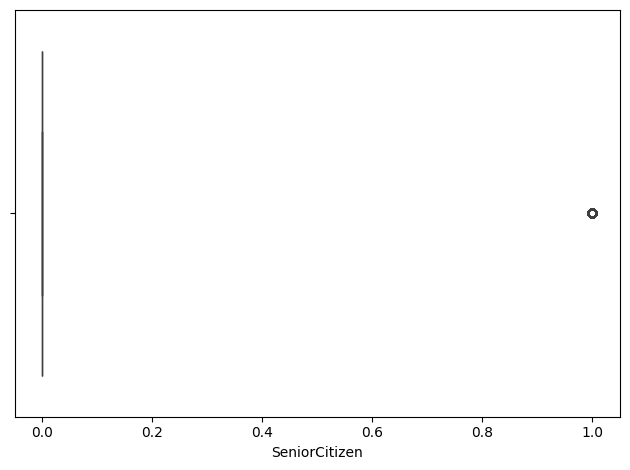

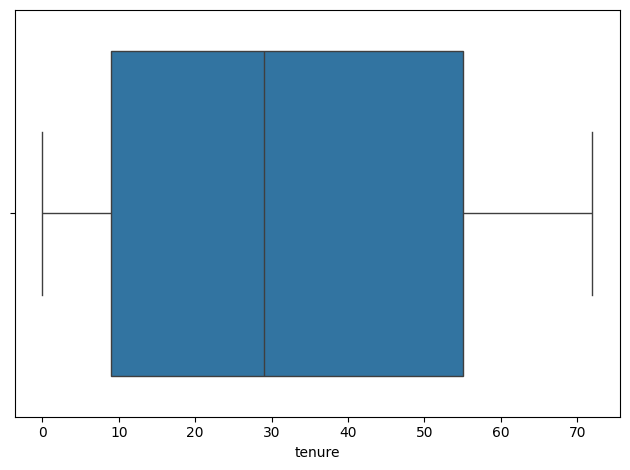

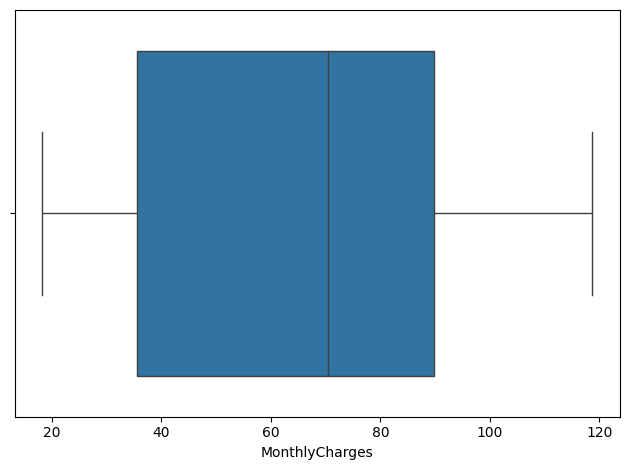

In [5]:
for col in df.select_dtypes('number'):
  sns.boxplot(data = df,x = col)
  plt.tight_layout()
  plt.show()

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [8]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

y = df['Churn'].map({'No': 0, 'Yes': 1})

X = df.drop(['Churn', 'customerID'], axis=1)

X = pd.get_dummies(X, drop_first=True)
X = X.astype(float)

In [9]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size= 0.2,random_state=42,stratify=y)

In [10]:
model = LogisticRegression(random_state=42)
model.fit(X_train,y_train)
print('Accuracy:',model.score(X_test,y_test))
y_pred = model.predict(X_test)

Accuracy: 0.8041163946061036


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


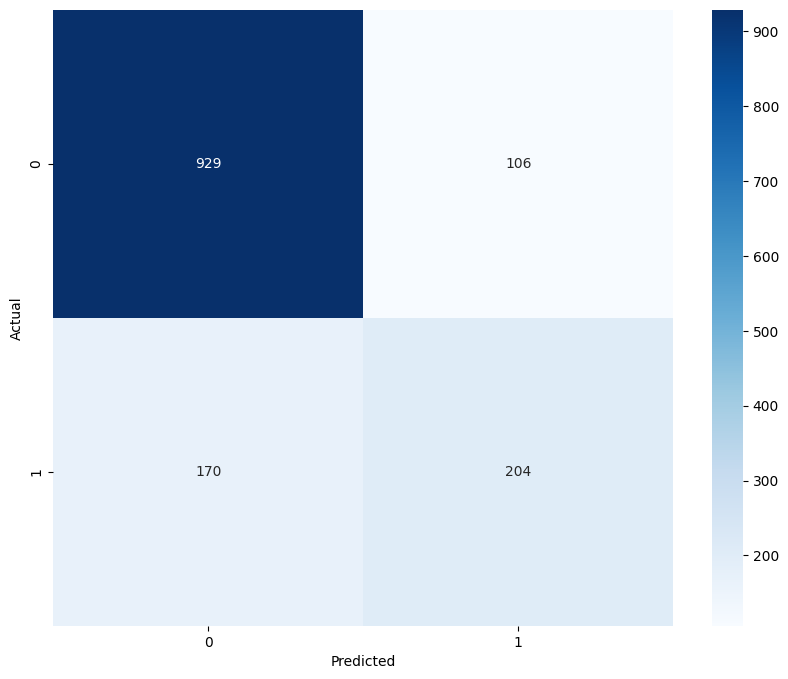

In [11]:
y_prob = model.predict_proba(X_test)[:,1]
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize = (10,8))
sns.heatmap(cm,annot=True,fmt = 'g',cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [12]:
print("recall_Score: ",recall_score(y_test,y_pred))
print("f1_score: ",f1_score(y_test,y_pred))

recall_Score:  0.5454545454545454
f1_score:  0.5964912280701754


In [13]:
display(classification_report(y_test,y_pred))

'              precision    recall  f1-score   support\n\n           0       0.85      0.90      0.87      1035\n           1       0.66      0.55      0.60       374\n\n    accuracy                           0.80      1409\n   macro avg       0.75      0.72      0.73      1409\nweighted avg       0.80      0.80      0.80      1409\n'

In [14]:
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

ROC-AUC  : 0.8419902348291094


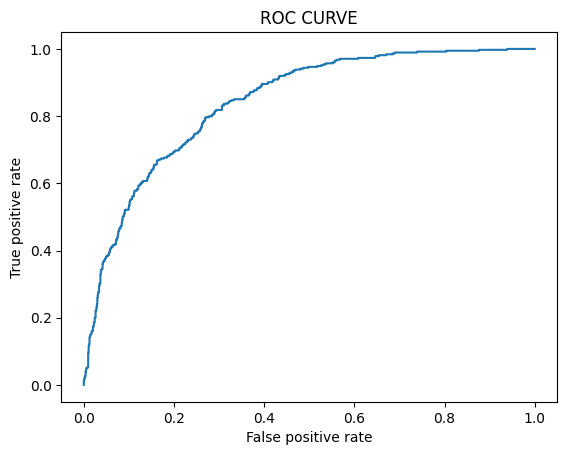

In [15]:
fpr,tpr,thresholds = roc_curve(y_test,y_prob)
plt.plot(fpr,tpr)
plt.plot([0,0],[1,1],linestyle = '--')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC CURVE')
plt.show()

In [16]:
churn_probablity = model.predict_proba(X_test)[:,1]
results = X_test.copy()
results['actual_values'] = y_test.values
results['predicted_values'] = y_pred
results['churn_proab'] = churn_probablity
results.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,actual_values,predicted_values,churn_proab
437,0.0,72.0,114.05,8468.20,1.0,1.0,1.0,1.0,0.0,1.0,...,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0,0,0.053518
2280,1.0,8.0,100.15,908.55,0.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0,1,0.666100
2235,0.0,41.0,78.35,3211.20,0.0,1.0,1.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0,0,0.070815
4460,0.0,18.0,78.20,1468.75,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0,0.340172
3761,0.0,72.0,82.65,5919.35,0.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0,0,0.032428


In [17]:
def risk_category(probability):

    if probability >= 0.70:
        return "High Risk"

    elif probability >= 0.40:
        return "Medium Risk"

    else:
        return "Low Risk"

In [18]:
results['RiskCategory'] = results['churn_proab'].apply(
    risk_category
)

results[['churn_proab', 'RiskCategory']].head()

,churn_proab,RiskCategory
437,0.053518,Low Risk
2280,0.666100,Medium Risk
2235,0.070815,Low Risk
4460,0.340172,Low Risk
3761,0.032428,Low Risk


In [19]:
ensemble = RandomForestClassifier(random_state = 42,n_estimators=10,max_depth=100)
ensemble.fit(X_train,y_train)
print("Accuracy: ",ensemble.score(X_test,y_test))
y_pred  = ensemble.predict(X_test)

Accuracy:  0.7814052519517388


In [20]:
display(classification_report(y_test,y_pred))

'              precision    recall  f1-score   support\n\n           0       0.82      0.89      0.86      1035\n           1       0.61      0.48      0.54       374\n\n    accuracy                           0.78      1409\n   macro avg       0.72      0.68      0.70      1409\nweighted avg       0.77      0.78      0.77      1409\n'

In [21]:
tree = DecisionTreeClassifier(random_state = 42,max_depth=100)
tree.fit(X_train,y_train)
print("Accuracy:", tree.score(X_test,y_test))
y_pred  = tree.predict(X_test)

Accuracy: 0.7260468417317246


In [22]:
svm = SVC(random_state = 42)
svm.fit(X_train,y_train)
print('Accuracy: ',svm.score(X_test,y_test))
y_pred = tree.predict(X_test)

Accuracy:  0.7345635202271115


In [23]:
logistic_regression = cross_val_score(model, X, y, cv=5, scoring='accuracy')
random_forest = cross_val_score(ensemble, X, y, cv=5, scoring='accuracy')
decision_tree = cross_val_score(tree, X, y, cv=5, scoring='accuracy')
svm_classifier = cross_val_score(svm, X, y, cv=5, scoring='accuracy')
print("Random Forest Accuracy: ",random_forest.mean() )
print("Logistic regression Accuracy: ",logistic_regression.mean() )
print("decision tree Accuracy: ",decision_tree.mean() )
print("svm classifier Accuracy: ",svm_classifier.mean() )

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Random Forest Accuracy:  0.7806344360926512
Logistic regression Accuracy:  0.8042040010645849
decision tree Accuracy:  0.7315075771017485
svm classifier Accuracy:  0.7346301575908123


### let us take the model of logistic which perform well on all aspect

In [24]:
from sklearn.cluster import KMeans,DBSCAN,AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler

In [25]:
segmentation_features = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'SeniorCitizen'
]

In [26]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [27]:
df[segmentation_features].head()

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen
0,1,29.85,29.85,0
1,34,56.95,1889.50,0
2,2,53.85,108.15,0
3,45,42.30,1840.75,0
4,2,70.70,151.65,0


In [28]:
df['ServiceCount'] = (
    (df['PhoneService'] == 'Yes').astype(int) +
    (df['InternetService'] != 'No').astype(int) +
    (df['OnlineSecurity'] == 'Yes').astype(int) +
    (df['OnlineBackup'] == 'Yes').astype(int) +
    (df['DeviceProtection'] == 'Yes').astype(int) +
    (df['TechSupport'] == 'Yes').astype(int) +
    (df['StreamingTV'] == 'Yes').astype(int) +
    (df['StreamingMovies'] == 'Yes').astype(int)
)

In [29]:
df['ServiceCount'].head()

,ServiceCount
0,2
1,4
2,4
3,4
4,2


In [30]:
segmentation_features = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'SeniorCitizen',
    'ServiceCount'
]

In [31]:
X_features  = df[segmentation_features].copy()
scaler  = StandardScaler()
X_features_scaled = scaler.fit_transform(X_features)

In [32]:
kval = range(2,11)
wcss = []
for k in kval:
  kmeans = KMeans(n_clusters = k,random_state= 42,n_init=10)
  kmeans.fit_predict(X_features_scaled)
  wcss.append(kmeans.inertia_)

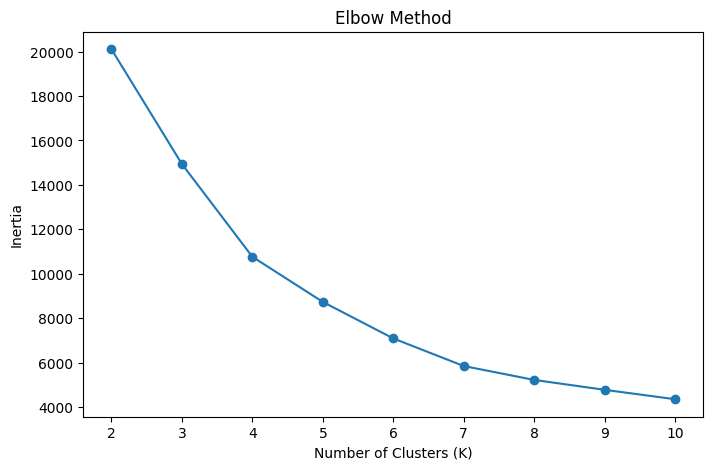

In [33]:
plt.figure(figsize=(8,5))

plt.plot(kval, wcss, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [34]:

kmeans = KMeans(n_clusters=4,random_state= 42, n_init=10)
df['clusters'] = kmeans.fit_predict(X_features_scaled)
clusters = kmeans.labels_
print("Accuracy: ",silhouette_score(X_features_scaled,clusters))

Accuracy:  0.4023961421511368


In [35]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ServiceCount,clusters
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,2,3
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,4,1
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,4,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,4,1
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,2,1


In [36]:

df['clusters'] = clusters

In [37]:
df['clusters'].head()

,clusters
0,3
1,1
2,1
3,1
4,1


In [38]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ServiceCount,clusters
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,2,3
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,4,1
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,4,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,4,1
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,2,1


In [39]:
cluster_profile = df.groupby('clusters')[segmentation_features].mean()

cluster_profile

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen,ServiceCount
clusters,,,,,
0,28.062626,76.072071,2163.196111,1.000000,3.803030
1,16.563933,73.123854,1185.008951,0.000000,3.913139
2,60.192057,90.293335,5430.204434,0.082699,6.039717
3,26.711864,25.167540,640.107088,0.000000,1.278891


In [40]:
segment_churn = pd.crosstab(
    df['clusters'],
    df['Churn'],
    normalize='index'
) * 100

segment_churn

Churn,No,Yes
clusters,,
0,54.141414,45.858586
1,59.479718,40.520282
2,87.268770,12.731230
3,86.543400,13.456600


In [41]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_features_scaled)

In [42]:
pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

pca_df['Cluster'] = df['clusters']

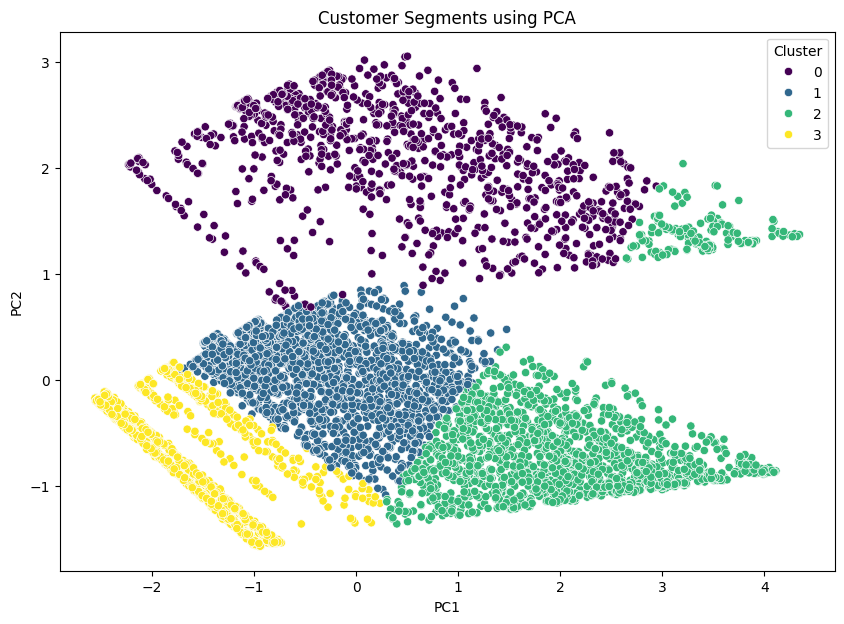

In [43]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='viridis'
)

plt.title("Customer Segments using PCA")
plt.show()

In [44]:
new_customers = pd.DataFrame({
    'tenure': [5, 60, 30, 10],
    'MonthlyCharges': [40, 90, 100, 50],
    'TotalCharges': [200, 5400, 3000, 500],
    'SeniorCitizen': [0, 0, 1, 0],
    'ServiceCount': [2, 6, 5, 1]
})

new_customers_scaled = scaler.transform(new_customers)

new_customers['PredictedCluster'] = kmeans.predict(
    new_customers_scaled
)

display(new_customers)

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen,ServiceCount,PredictedCluster
0,5,40,200,0,2,3
1,60,90,5400,0,6,2
2,30,100,3000,1,5,0
3,10,50,500,0,1,3


The K-Means model identified four customer segments based on tenure, monthly charges, total charges, senior-citizen status, and service adoption. New customers can then be assigned to the nearest learned segment using the trained K-Means model.`

In [45]:
all_churn_probability = model.predict_proba(X)[:, 1]

df['ChurnProbability'] = all_churn_probability

df['RiskCategory'] = df['ChurnProbability'].apply(
    risk_category
)

In [46]:
customer_intelligence = df[
    [
        'customerID',
        'tenure',
        'MonthlyCharges',
        'TotalCharges',
        'ServiceCount',
        'clusters',
        'ChurnProbability',
        'RiskCategory',
        'Churn'
    ]
].copy()

customer_intelligence.head(10)

,customerID,tenure,MonthlyCharges,TotalCharges,ServiceCount,clusters,ChurnProbability,RiskCategory,Churn
0,7590-VHVEG,1,29.85,29.85,2,3,0.627540,Medium Risk,No
1,5575-GNVDE,34,56.95,1889.50,4,1,0.053625,Low Risk,No
2,3668-QPYBK,2,53.85,108.15,4,1,0.294147,Low Risk,Yes
3,7795-CFOCW,45,42.30,1840.75,4,1,0.031216,Low Risk,No
4,9237-HQITU,2,70.70,151.65,2,1,0.701851,High Risk,Yes
5,9305-CDSKC,8,99.65,820.50,5,1,0.785699,High Risk,Yes
6,1452-KIOVK,22,89.10,1949.40,4,1,0.464118,Medium Risk,No
7,6713-OKOMC,10,29.75,301.90,2,3,0.266747,Low Risk,No
8,7892-POOKP,28,104.80,3046.05,6,1,0.561428,Medium Risk,Yes
9,6388-TABGU,62,56.15,3487.95,4,2,0.013086,Low Risk,No


In [47]:
def recommendation(row):

    if row['RiskCategory'] == 'High Risk':

        if row['clusters'] == 0:
            return "Priority retention campaign and personalized support"

        elif row['clusters'] == 1:
            return "Early-tenure retention offer and onboarding support"

        elif row['clusters'] == 2:
            return "Premium retention offer and loyalty benefits"

        else:
            return "Targeted engagement campaign"

    elif row['RiskCategory'] == 'Medium Risk':
        return "Monitor customer and provide targeted engagement"

    else:
        return "Maintain relationship and consider loyalty benefits"

In [48]:
customer_intelligence['Recommendation'] = (
    customer_intelligence.apply(
        recommendation,
        axis=1
    )
)

In [49]:
customer_intelligence.head(10)

,customerID,tenure,MonthlyCharges,TotalCharges,ServiceCount,clusters,ChurnProbability,RiskCategory,Churn,Recommendation
0,7590-VHVEG,1,29.85,29.85,2,3,0.627540,Medium Risk,No,Monitor customer and provide targeted engagement
1,5575-GNVDE,34,56.95,1889.50,4,1,0.053625,Low Risk,No,Maintain relationship and consider loyalty ben...
2,3668-QPYBK,2,53.85,108.15,4,1,0.294147,Low Risk,Yes,Maintain relationship and consider loyalty ben...
3,7795-CFOCW,45,42.30,1840.75,4,1,0.031216,Low Risk,No,Maintain relationship and consider loyalty ben...
4,9237-HQITU,2,70.70,151.65,2,1,0.701851,High Risk,Yes,Early-tenure retention offer and onboarding su...
5,9305-CDSKC,8,99.65,820.50,5,1,0.785699,High Risk,Yes,Early-tenure retention offer and onboarding su...
6,1452-KIOVK,22,89.10,1949.40,4,1,0.464118,Medium Risk,No,Monitor customer and provide targeted engagement
7,6713-OKOMC,10,29.75,301.90,2,3,0.266747,Low Risk,No,Maintain relationship and consider loyalty ben...
8,7892-POOKP,28,104.80,3046.05,6,1,0.561428,Medium Risk,Yes,Monitor customer and provide targeted engagement
9,6388-TABGU,62,56.15,3487.95,4,2,0.013086,Low Risk,No,Maintain relationship and consider loyalty ben...


In [50]:
risk_segment = pd.crosstab(
    df['clusters'],
    df['RiskCategory']
)

risk_segment

RiskCategory,High Risk,Low Risk,Medium Risk
clusters,,,
0,222,396,372
1,288,1084,896
2,0,1764,74
3,7,1742,198
